# Simulated IRFs from RBC Model

This code creates a very simple RBC model with random technology shocks. Data from this model is simulated, the true IRFs are created, and then the IRFs are estimated using VAR and SLP estimation.

The model has period utility $u_t=\log(C_t)$, production function $Y_t = e^{z_t}K^{\alpha}_t$, and technology evolution $z_{t+1} = \rho z_t+\varepsilon_{t+1}$. The econometrician observes $K_t, Y_t, Z_t$ with noise, where $Z_t=e^{z_t}$. The advantage of this simple model is that the policy funciton of the household has a closed-form solution.

In [1]:
# import packages
import statsmodels as sm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.api import VAR

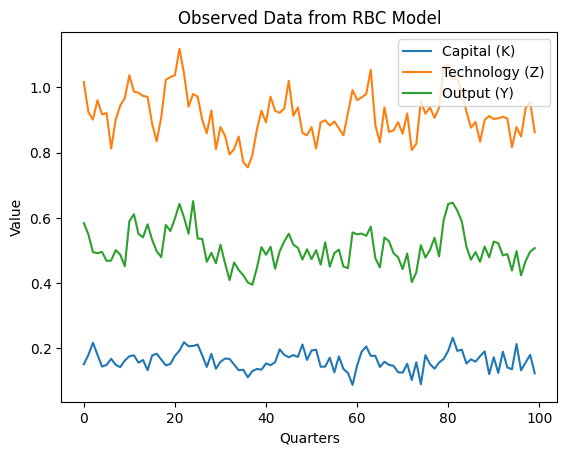

In [2]:
# create simulated time series data for simple RBC model (log utility, Cobb-Douglas production function, inelastic labor supply, full depreciation)
np.random.seed(1371)
def gen_macro_ts(beta, alpha, rho, sigma, T):
    ss_K = (1/(beta*alpha))**(1/(alpha-1))
    ss_C = ss_K**alpha - ss_K

    K = np.zeros(T)
    C = K.copy()
    z = K.copy()
    Y = K.copy()

    K[0] = ss_K
    C[0] = ss_C
    Y[0] = K[0]**alpha

    for t in range(1, T):
        z[t] = rho * z[t-1] + sigma * np.random.normal()
        K[t] = alpha * beta * np.exp(z[t-1]) * K[t-1]**alpha
        C[t] = (1-alpha*beta) * np.exp(z[t]) * K[t]**alpha
        
    Z = np.exp(z) + np.random.normal(0, 0.025, size=T) # add small measurement error to observed Z
    Y = Z*K**alpha + np.random.normal(0, 0.025, size=T) # add small measurement error to observed Y
    K = K + np.random.normal(0, 0.025, size=T) # add small measurement error to observed K


    return pd.DataFrame({"K": K, "Z": Z, "Y": Y})

observed_data = gen_macro_ts(beta=0.99, alpha=0.33, rho = 0.9, sigma = 0.05, T=100)

plt.plot(observed_data)
plt.title("Observed Data from RBC Model")
plt.xlabel("Quarters")
plt.ylabel("Value")
plt.legend(["Capital (K)", "Technology (Z)", "Output (Y)"])
plt.show()

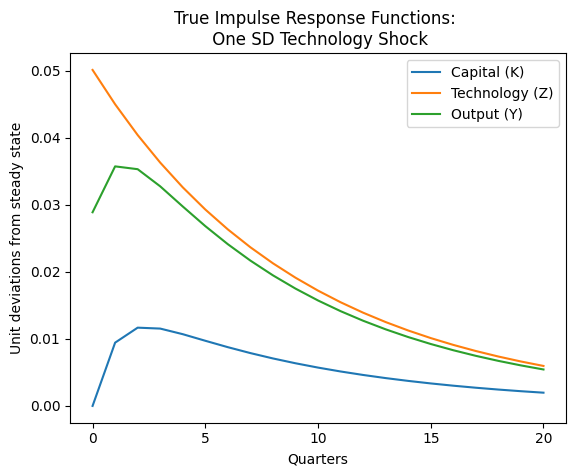

In [3]:
# simulated IRF for a one SD technology shock based on RBC model 
# this is the true IRF that the econometrician is trying to estimate from observed data
def gen_irf(beta, alpha, rho, sigma, q):
    ss_K = (1/(beta*alpha))**(1/(alpha-1))
    ss_C = ss_K**alpha - ss_K

    K = np.zeros(q)
    C = K.copy()
    z = K.copy()
    Y = K.copy()

    z[0] = np.log(np.sqrt((np.exp(sigma**2)-1)*np.exp(sigma**2))+1) # one SD shock to observed Z
    K[0] = ss_K
    C[0] = ss_C

    for t in range(1, q):
        z[t] = rho * z[t-1]
        K[t] = alpha * beta * np.exp(z[t-1]) * K[t-1]**alpha
        C[t] = (1-alpha*beta) * np.exp(z[t]) * K[t]**alpha

    Z = np.exp(z) - 1
    Y = np.exp(z)*K**alpha - ss_K**alpha
    K = K - ss_K

    return pd.DataFrame({"K": K, "Z": Z, "Y": Y,})

true_irf = gen_irf(beta=0.99, alpha=0.33, rho = 0.9, sigma = 0.05, q=21)

plt.plot(true_irf)
plt.title("True Impulse Response Functions: \n One SD Technology Shock")
plt.xlabel("Quarters")
plt.ylabel("Unit deviations from steady state")
plt.xticks(range(0, 21, 5))
plt.legend(["Capital (K)", "Technology (Z)" , "Output (Y)"])
plt.show()

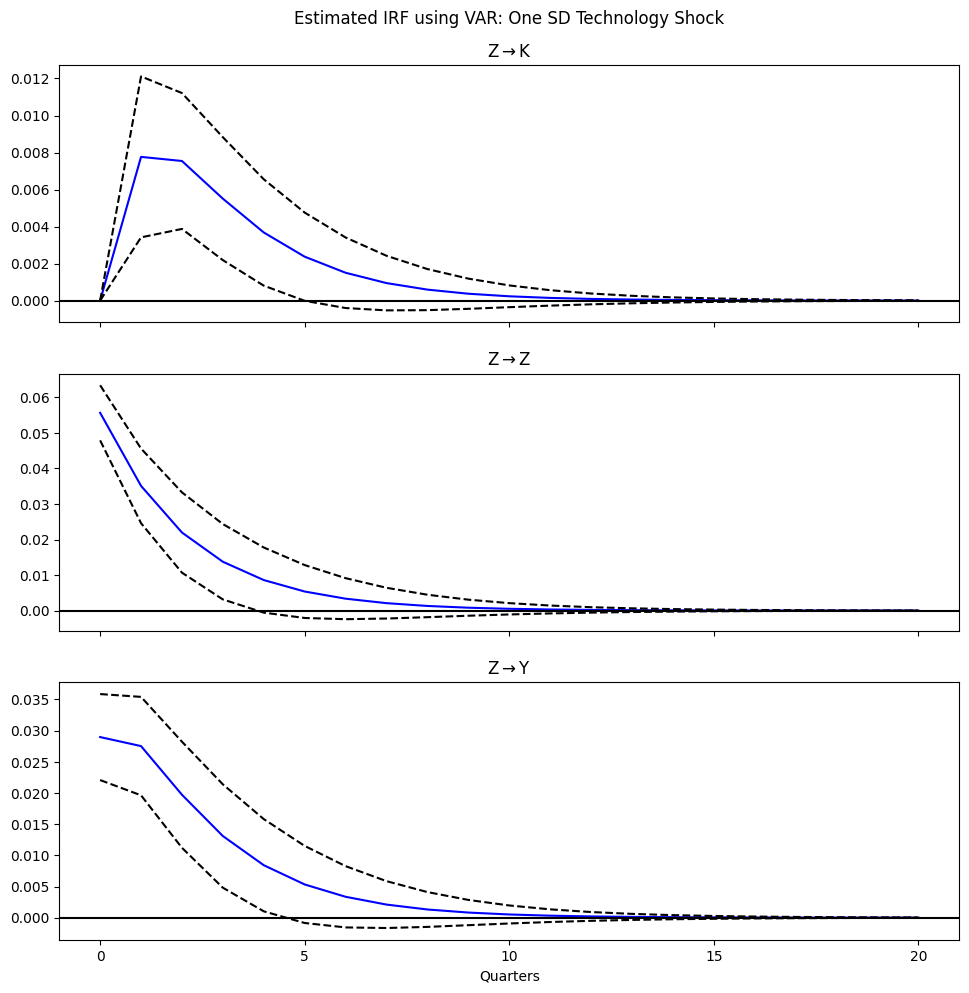

In [4]:
# estimated IRF using VAR model on observed data
def estimate_irf(data, T):
    model = VAR(data)
    results = model.fit(ic="aic")
    irf = results.irf(T)
    return irf
VAR_irf = estimate_irf(observed_data, T=20)
VAR_irf.plot(orth=True, impulse = "Z")
plt.suptitle("Estimated IRF using VAR: One SD Technology Shock")
plt.xlabel("Quarters")
plt.xticks(range(0, 21, 5))
plt.show()

In [5]:
# estimated IRF using SLP model on observed data

